# Simulating the Modulation Curve Numerically

The next equation is going to be simulated:

$$I_k (x,y) = exp(\lambda_k)*[a_0(x,y)+a_1(x,y)*cos(\frac{2\pi k}{M}+\Phi(x,y) + step\_error_k)]+\eta_k(x,y)$$

Where $I(x,y)$ is the intensity in each $(x,y)$ pixel, $\lambda$ is the mean value of a normal distribution to simulate the Dose Fluctuations between each acquisition. The $step\_error$ simulates errors in the phase step estimation and $\eta$ the noise. The parameters related to the Differential Phase Contrast (DPC) and Attenuation or Transmission (T) images are $a_0(x,y)$, $a_1(x,y)$ and $\Phi(x,y)$. 

First it is needed to define the object we want to simulate, there are only simple objects like a sphere or a cylinder.

Fresnel number: 0.16131088581590397.


Fresnel number: 0.16131088581590397.


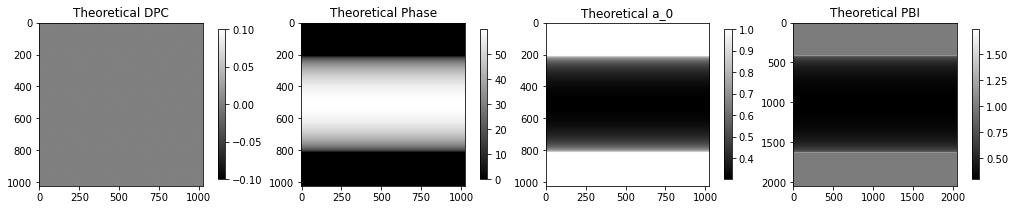

Fresnel number: 0.16131088581590397.


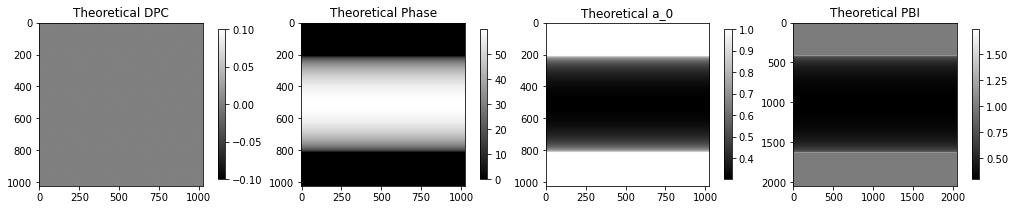

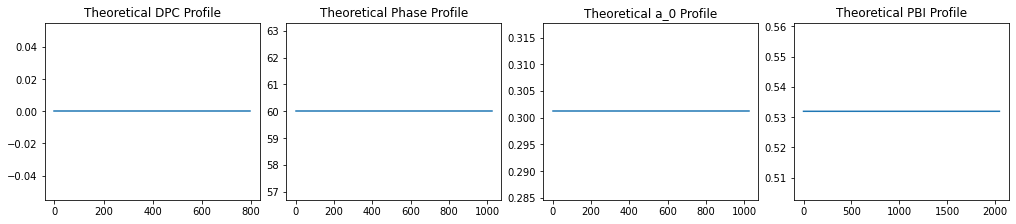

In [1]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

import src.Simple_Numerical_Simulation.Objects as obj
import src.Simple_Numerical_Simulation.simulation as sim

n = 1024
radius = 300 # um
pixel_size = 1 #um
delta = 1E-1 # Real part of refractive index multiplied by 2*pi/wavelength
beta = 1E-3 # The imaginary part  of refractive index multiplied by 2*pi/wavelength

Object = obj.Cylinder(n, radius, pixel_size, delta, beta,'Vertical')

#Object = obj.Wedge(n, 300,400, pixel_size, delta, beta)


PG = Object.Obtain_Phase_Gradient(axis = 1)
Lp = Object.Obtain_Phase_Laplacian()
Phase = Object.Obtain_Phase_Distribuction()
a0 = Object.a0_Distribution()
PBI_theor = Object.PBI_Theoretical_near_field(distance = 10, energy = 20, M = 2)
#imageio.imwrite('Simulation/Phase.tif', Phase)

fig, ax = plt.subplots(1, 4, constrained_layout = True, figsize = (14, 14))
#fig.tight_layout()

DPC = ax[0].imshow(PG,  'gray')
ax[0].title.set_text('Theoretical DPC')
fig.colorbar(DPC, ax = ax[0], fraction=0.046, pad=0.04)

P = ax[1].imshow(Phase,  'gray')
ax[1].title.set_text('Theoretical Phase')
fig.colorbar(P, ax = ax[1], fraction=0.046, pad=0.04)

A0 = ax[2].imshow(a0,  'gray')
ax[2].title.set_text('Theoretical a_0')
fig.colorbar(A0, ax = ax[2], fraction=0.046, pad=0.04)

PBI_THEOR = ax[3].imshow(PBI_theor,  'gray')
ax[3].title.set_text('Theoretical PBI')
fig.colorbar(PBI_THEOR, ax = ax[3], fraction=0.046, pad=0.04)
plt.show()
#fig.savefig('Theoretical_Sphere.png')

fig, ax = plt.subplots(1, 4, constrained_layout = True, figsize = (14, 3))
DPC_Profile = ax[0].plot(PG[n//2, 100:900])
ax[0].title.set_text('Theoretical DPC Profile')

P_Profile = ax[1].plot(Phase[n//2, :])
ax[1].title.set_text('Theoretical Phase Profile')

A0_Profile =ax[2].plot(a0[n//2, :])
ax[2].title.set_text('Theoretical a_0 Profile')

PBI_THEOR_Profile =ax[3].plot(PBI_theor[n//2, :])
ax[3].title.set_text('Theoretical PBI Profile')
plt.show()
#fig.savefig('Theoretical_Sphere_Profiles.png')

Now we can simulate the Modulation Curves based on the previous equation.

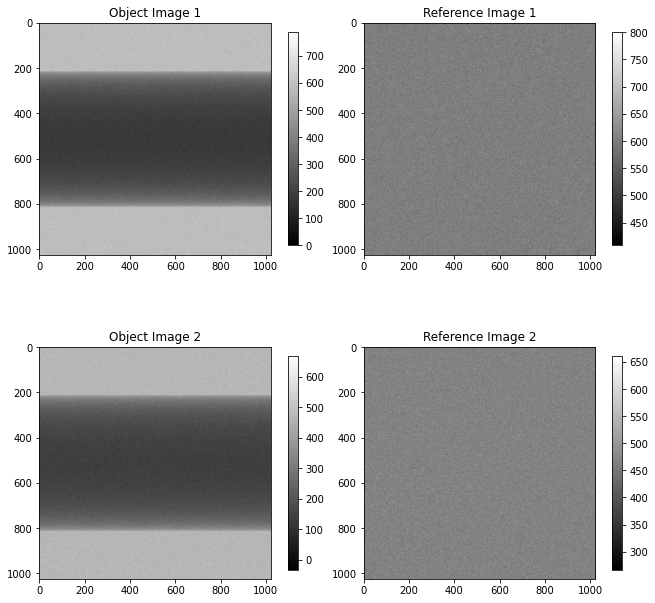

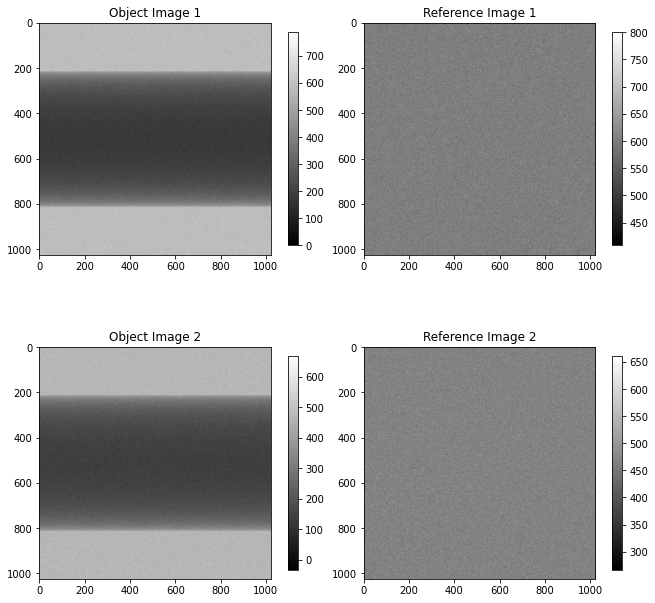

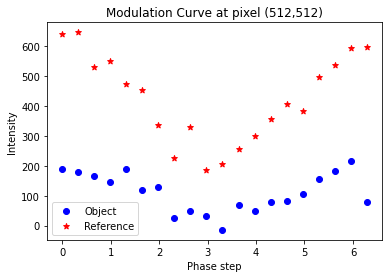

In [2]:
noise_mean = 0.1
error_steps_mean = 0.00
error_dose_mean = 0.02
Moire = False
Phase_steps = 20
Images, Images_reference = sim.Simulation(Object, Phase_steps, noise_mean, error_steps_mean, error_dose_mean, Moire)
Images = np.asarray(Images)
Images_reference = np.asarray(Images_reference)
#print(Images)
Images *= 400
Images_reference *= 400

fig, ax = plt.subplots(2, 2, constrained_layout = True, figsize = (9, 9))
#fig.tight_layout()

Imag1 = ax[0,0].imshow(Images[0,:,:],  'gray')
ax[0,0].title.set_text('Object Image 1')
fig.colorbar(Imag1, ax = ax[0,0], fraction=0.046, pad=0.04)

RefImage1 = ax[0,1].imshow(Images_reference[0,:,:],  'gray')
ax[0,1].title.set_text('Reference Image 1')
fig.colorbar(RefImage1, ax = ax[0,1], fraction=0.046, pad=0.04)

Imag2 = ax[1,0].imshow(Images[4,:,:],  'gray')
ax[1,0].title.set_text('Object Image 2')
fig.colorbar(Imag2, ax = ax[1,0], fraction=0.046, pad=0.04)

RefImage2 = ax[1,1].imshow(Images_reference[4,:,:],  'gray')
ax[1,1].title.set_text('Reference Image 2')
fig.colorbar(RefImage2, ax = ax[1,1], fraction=0.046, pad=0.04)
plt.show()

plt.scatter(np.linspace(0,2*np.pi, Phase_steps), Images[:,n//2, n//2],color= "blue",marker= "o", label = 'Object')
plt.scatter(np.linspace(0,2*np.pi, Phase_steps), Images_reference[:,n//2, n//2], color= "red",marker= "*", label = 'Reference')
plt.legend(loc='best')
plt.xlabel('Phase step')
plt.ylabel('Intensity')
plt.title(f'Modulation Curve at pixel ({n//2},{n//2})')
plt.show()
#fig.savefig('Modulation_Curve.png')

We can save the results into the **Simulation** folder or modifying the path, wherever you want.

In [ ]:
import tifffile as tiff

filename_object_images = 'Sphere'
filename_reference_images = 'Sphere_reference'
tiff.imwrite('Simulation/'+str(filename_object_images)+'.tif')
tiff.imwrite('Simulation/'+str(filename_reference_images)+'.tif')

399.99749999218744


399.99749999218744


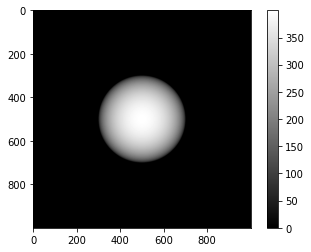

399.99749999218744


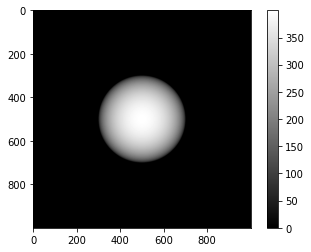

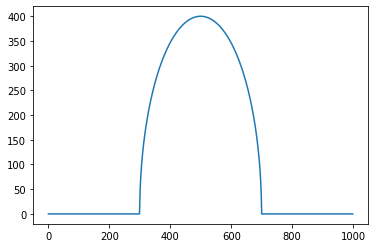

399.99749999218744


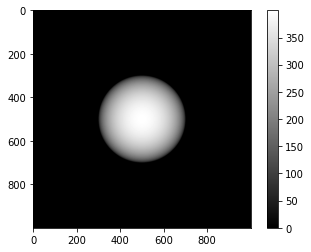

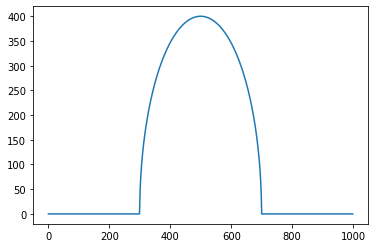

161.2580747332259


399.99749999218744


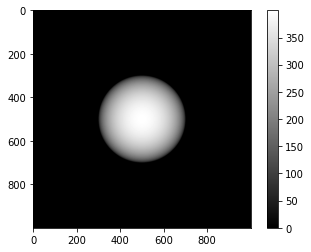

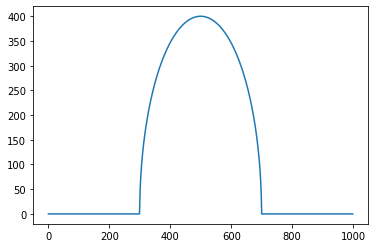

161.2580747332259


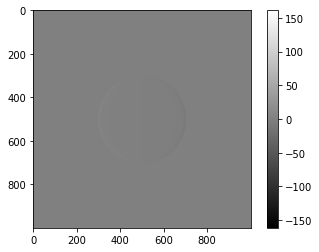

399.99749999218744


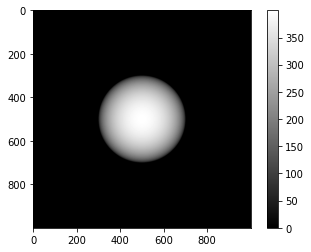

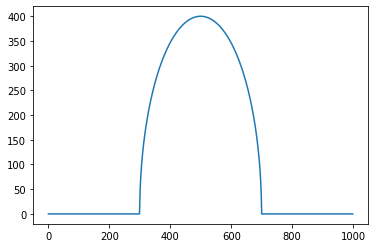

161.2580747332259


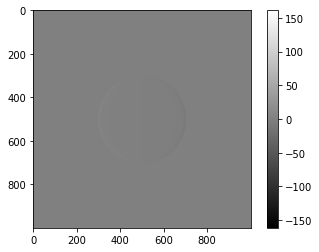

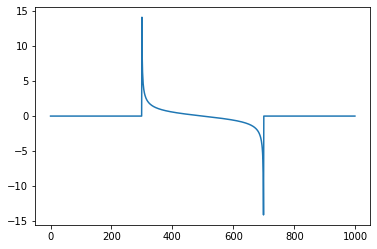

399.99749999218744


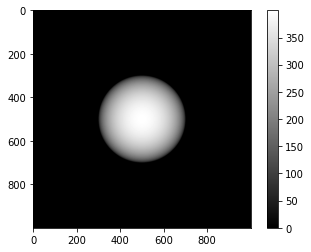

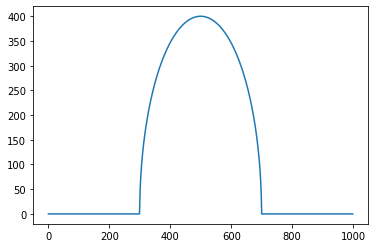

161.2580747332259


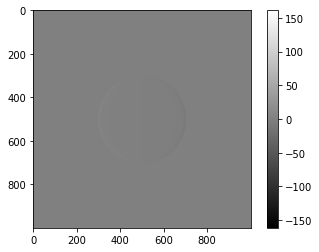

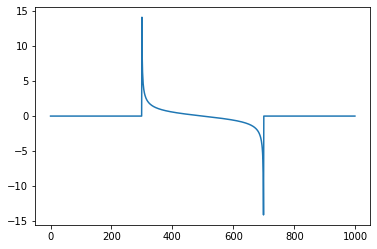

0.0


399.99749999218744


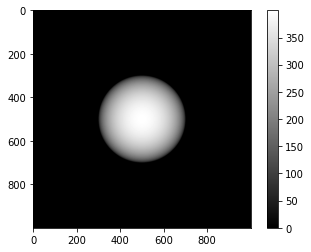

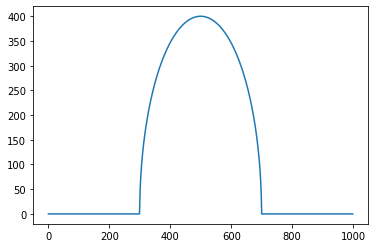

161.2580747332259


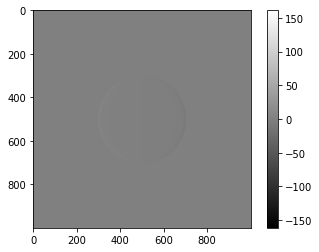

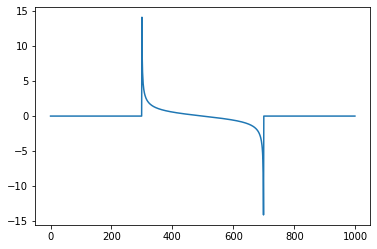

0.0


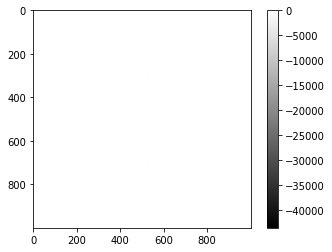

399.99749999218744


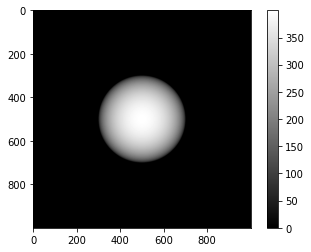

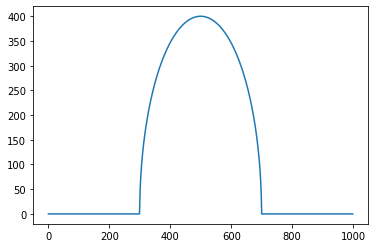

161.2580747332259


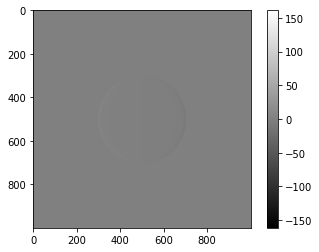

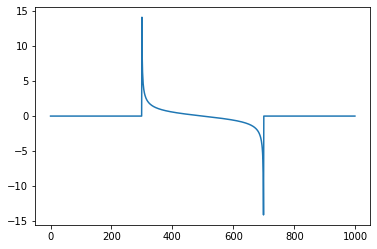

0.0


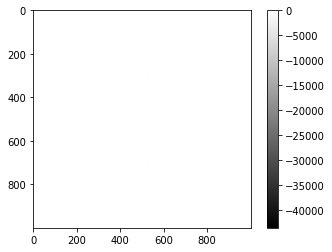

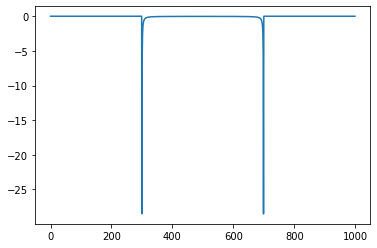

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n = 1000
pixel_size = 1
radius = 200
x,y = np.mgrid[(-n-0)//2 : (n-0)//2, (-n-0)//2 : (n-0)//2]
x = (x+0.5)*pixel_size 
y = (y+0.5)*pixel_size
thickness = np.zeros((n,n))
gradient = np.zeros((n,n))
laplacian = np.zeros((n,n))
sph = np.where(x**2+y**2<radius**2)
#image[sph] = 2*(-2/np.sqrt(radius**2 - x[sph]**2 -y[sph]**2)+ 2*x[sph]**2/(2*np.sqrt(radius**2 - x[sph]**2 -y[sph]**2)**3)+ 2*y[sph]**2/(2*np.sqrt(radius**2 - x[sph]**2 -y[sph]**2)**3))
laplacian[sph] = 2*((-2*radius**2 + x[sph]**2 + y[sph]**2)/(radius**2 - x[sph]**2 - y[sph]**2)**(3/2))  #Laplacian
gradient[sph] = -y[sph]/np.sqrt(radius**2-x[sph]**2-y[sph]**2) #gradient
thickness[sph] = 2*np.sqrt(radius**2-x[sph]**2-y[sph]**2)

print(np.max(thickness))
plt.imshow(thickness, 'gray')
plt.colorbar()
plt.show()

plt.plot(thickness[500,:])
plt.show()

print(np.max(gradient))
plt.imshow(gradient, 'gray')
plt.colorbar()
plt.show()

plt.plot(gradient[500,:])
plt.show()

print(np.max(laplacian))
plt.imshow(laplacian, 'gray')
plt.colorbar()
plt.show()

plt.plot(laplacian[500,:])
plt.show()

# Dataset Generation

## Quick Guide: Random TL Dataset Generation

This section generates synthetic Talbot-Lau data with random geometries and optional inserts, and provides both phase-stepping images and physical ground truth maps.

### What this workflow does
- Builds a random multi-object scene.
- Computes ground truth maps: thickness, phase, transmission, and DPC.
- Simulates object/reference phase-stepping image stacks.
- Saves TIFF stacks for reconstruction.

###  Execution order
1. Run the following cell.
2. Retrieve the PCI images using the TLRec module.
### Key parameters
- `material_library`: use physical `delta` and `beta` values (not pre-scaled).
- `energy_keV`: used to internally convert to $k\delta$ and $k\beta$.
- `object_count_range`: number of random objects per scene.
- `allow_inserts`, `insert_probability`, `max_inserts_per_object`: control insert complexity.
- `noise_mean`, `error_steps_mean`, `error_dose_mean`: instrument/noise realism.

### Main outputs
- `sample["phase_map"]`: accumulated phase map.
- `sample["transmission_map"]`: transmission map ($a_0$).
- `sample["phase_gradient"]`: theoretical DPC map.
- `sample["images"]` and `sample["images_reference"]`: phase-stepping stacks.

### Practical tip
Start with zero (or very low) noise to validate reconstruction, then gradually increase noise and phase-step errors to test robustness.

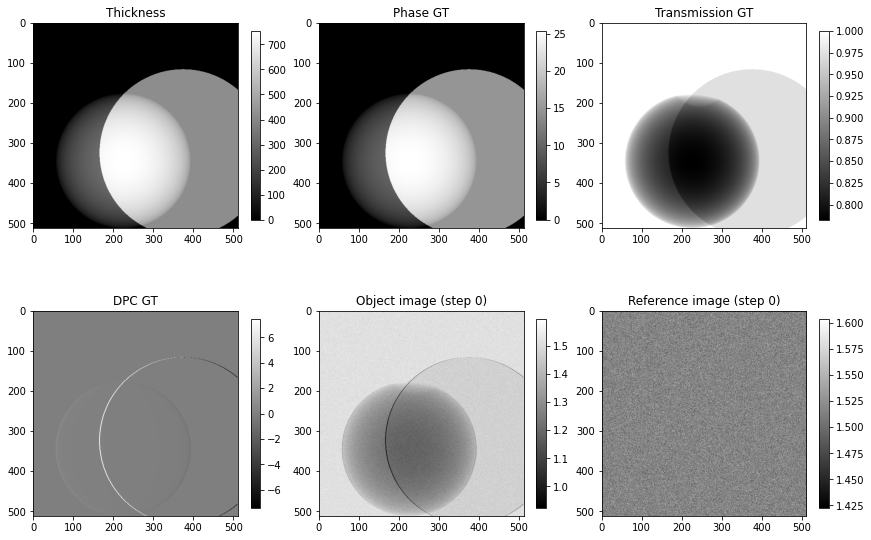

In [4]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from src.Simple_Numerical_Simulation.Objects import RandomSimGenerator
from src.Simple_Numerical_Simulation import simulation as sim

materials = [
    {"delta": 4.8e-7, "beta": 1.4e-10},
    {"delta": 3.5e-7, "beta": 3.2e-10},
    {"delta": 3.1e-7, "beta": 3.2e-9},
]

gen = RandomSimGenerator(n=512, pixel_size=1.0, material_library=materials, energy_keV=20.0, object_count_range=(2, 5),
    allow_inserts=True, insert_probability=0.6, max_inserts_per_object=2)

sample = sim.simulate_random_tl_sample(generator=gen, phase_steps=20, noise_mean=0.02, error_steps_mean=0.01,
    error_dose_mean=0.01, axis=1, moire=False)

phase_gt = sample["phase_map"]
trans_gt = sample["transmission_map"]
dpc_gt = sample["phase_gradient"]
images = sample["images"]
images_ref = sample["images_reference"]

os.makedirs("Simulation", exist_ok=True)
tiff.imwrite("Simulation/images_object.tif", images.astype(np.float32))
tiff.imwrite("Simulation/images_reference.tif", images_ref.astype(np.float32))


fig, ax = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

im0 = ax[0,0].imshow(sample["thickness_map"], cmap="gray")
ax[0,0].set_title("Thickness")
plt.colorbar(im0, ax=ax[0,0], fraction=0.046, pad=0.04)

im1 = ax[0,1].imshow(phase_gt, cmap="gray")
ax[0,1].set_title("Phase GT")
plt.colorbar(im1, ax=ax[0,1], fraction=0.046, pad=0.04)

im2 = ax[0,2].imshow(trans_gt, cmap="gray")
ax[0,2].set_title("Transmission GT")
plt.colorbar(im2, ax=ax[0,2], fraction=0.046, pad=0.04)

im3 = ax[1,0].imshow(dpc_gt, cmap="gray")
ax[1,0].set_title("DPC GT")
plt.colorbar(im3, ax=ax[1,0], fraction=0.046, pad=0.04)

im4 = ax[1,1].imshow(images[0], cmap="gray")
ax[1,1].set_title("Object image (step 0)")
plt.colorbar(im4, ax=ax[1,1], fraction=0.046, pad=0.04)

im5 = ax[1,2].imshow(images_ref[0], cmap="gray")
ax[1,2].set_title("Reference image (step 0)")
plt.colorbar(im5, ax=ax[1,2], fraction=0.046, pad=0.04)

plt.show()

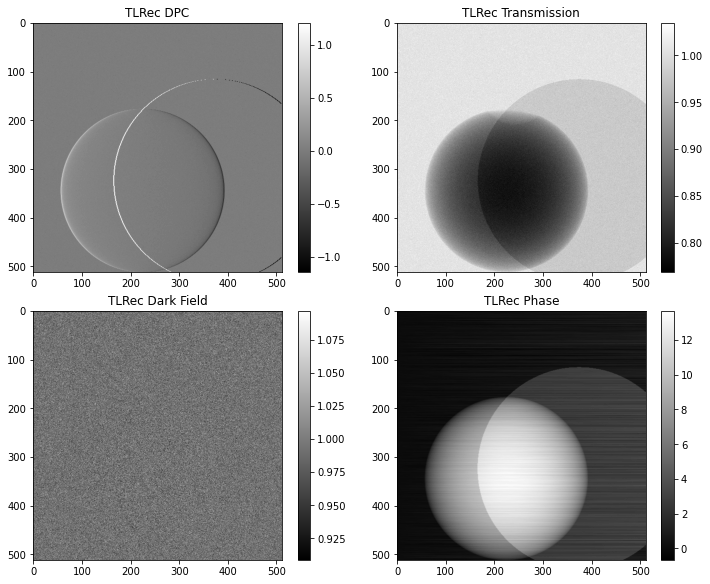

MAE Transmission vs GT: 6.5627e-03
MAE Phase vs GT: 5.6455e+00
Saved TLRec outputs in Simulation/TLRec


In [5]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), os.pardir)))

import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from src.TLRec.Experimental_Retrieval import Modulation_Curve_Reconstruction

G2Period_um = 4.8
DSO_cm = 100.0
DOD_cm = 20.0
DG1O_cm = 10.0
energy_keV = 20.0
pixel_size_um = 1.0
retrieval_type = 'Fast_FFT'  # 'FFT', 'Fast_FFT', 'least_squares', 'fast_lstsq', 'Step_correction'

DPC_rec, T_rec, DF_rec, Phase_rec, p_ref, p_obj = Modulation_Curve_Reconstruction(
    images=images,images_reference=images_ref,G2Period=G2Period_um,DSO=DSO_cm,DOD=DOD_cm,
    DG1O=DG1O_cm,energy=energy_keV,pixel_size=pixel_size_um,type=retrieval_type,unwrap_phase=False)

fig, ax = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

im0 = ax[0,0].imshow(DPC_rec, cmap='gray')
ax[0,0].set_title('TLRec DPC')
plt.colorbar(im0, ax=ax[0,0], fraction=0.046, pad=0.04)

im1 = ax[0,1].imshow(T_rec, cmap='gray')
ax[0,1].set_title('TLRec Transmission')
plt.colorbar(im1, ax=ax[0,1], fraction=0.046, pad=0.04)

im2 = ax[1,0].imshow(DF_rec, cmap='gray')
ax[1,0].set_title('TLRec Dark Field')
plt.colorbar(im2, ax=ax[1,0], fraction=0.046, pad=0.04)

im3 = ax[1,1].imshow(Phase_rec, cmap='gray')
ax[1,1].set_title('TLRec Phase')
plt.colorbar(im3, ax=ax[1,1], fraction=0.046, pad=0.04)

plt.show()

if 'trans_gt' in globals():
    mae_t = np.mean(np.abs(T_rec - trans_gt))
    print(f'MAE Transmission vs GT: {mae_t:.4e}')
if 'phase_gt' in globals():
    mae_p = np.mean(np.abs(Phase_rec - phase_gt))
    print(f'MAE Phase vs GT: {mae_p:.4e}')

os.makedirs('Simulation/TLRec', exist_ok=True)
tiff.imwrite('Simulation/TLRec/DPC_rec.tif', DPC_rec.astype(np.float32))
tiff.imwrite('Simulation/TLRec/Transmission_rec.tif', T_rec.astype(np.float32))
tiff.imwrite('Simulation/TLRec/DarkField_rec.tif', DF_rec.astype(np.float32))
tiff.imwrite('Simulation/TLRec/Phase_rec.tif', Phase_rec.astype(np.float32))
print('Saved TLRec outputs in Simulation/TLRec')